In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import Conv2d, BatchNorm2d, SiLU, Identity, Module, Sequential
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
import random

In [12]:
def get_mnist_dataloaders(batch_size=64):
    train_dataset = datasets.MNIST(
        root='./data',
        train=True,
        download=True,
        transform=ToTensor()
    )

    test_dataset = datasets.MNIST(
        root='./data',
        train=False,
        download=True,
        transform=ToTensor()
    )

    train_loader = DataLoader(
        dataset=train_dataset, 
        batch_size=batch_size, 
        shuffle=True,   
    )

    test_loader = DataLoader(
        dataset=test_dataset, 
        batch_size=batch_size, 
        shuffle=False,
    )

    return train_loader, test_loader

train_loader, test_loader = get_mnist_dataloaders(batch_size=64)

images, labels = next(iter(train_loader))
print(f"Feature batch shape: {images.shape}")
print(f"Labels batch shape: {labels.shape}")

Feature batch shape: torch.Size([64, 1, 28, 28])
Labels batch shape: torch.Size([64])


In [13]:
class Conv(Sequential):
    def __init__(self, cin, cout, k=3, norm=True, act="silu"):
        super().__init__(
        BatchNorm2d(cin) if norm else Identity(),
        Conv2d(cin, cout, k, padding="same"),
        {"none": Identity(), "silu":SiLU()}[act]
        )
class DoubleConv(Sequential):
    def __init__(self, cin, cout, k=3, norm=True, act="silu"):
        super().__init__(
            Conv(cin, cout, k, norm, act),
            Conv(cout, cout, k, norm, act)
        )

In [14]:
class CNN(Module):
    def __init__(self, c):
        super().__init__()
        self.cnn = Sequential(
            DoubleConv(1, c),
            DoubleConv(c, c*2),
            DoubleConv(c*2, c*4))

        self.cls = nn.Linear(c*4, 10)

    def forward(self, x):
        x = F.pad(x, [2,2,2,2])
        x = self.cnn(x)
        x = x.mean((2,3))
        x = self.cls(x)
        return x

In [15]:
class UNET(Module):
    def __init__(self, c):
        super().__init__()
        self.d1 = DoubleConv(2, c)
        self.d2 = DoubleConv(c, c*2)
        self.d3 = DoubleConv(c*2, c*4)

        self.bn = DoubleConv(c*4, c*4)

        self.u3 = DoubleConv(c*8, c*2)
        self.u2 = DoubleConv(c*4, c)
        self.u1 = DoubleConv(c*2, c)
        self.u0 = DoubleConv(c, 1, act="none")

    def forward(self, x):
        x = F.pad(x, [2,2,2,2])
        x1 = F.max_pool2d(self.d1(x), 2, 2)
        x2 = F.max_pool2d(self.d2(x1), 2, 2)
        x3 = F.max_pool2d(self.d3(x2), 2, 2)

        x = self.bn(x3)

        x = F.interpolate(self.u3(torch.cat([x3, x], dim=1)), scale_factor=2)
        x = F.interpolate(self.u2(torch.cat([x2, x], dim=1)), scale_factor=2)
        x = F.interpolate(self.u1(torch.cat([x1, x], dim=1)), scale_factor=2)
        x = self.u0(x)
        x = F.pad(x, [-2,-2,-2,-2])
        return x

In [16]:
cnn = CNN(16).cuda()
optim_cnn = torch.optim.Adam(cnn.parameters(), fused=True)

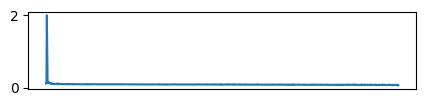

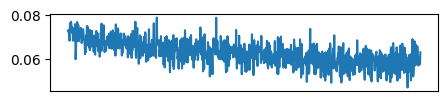

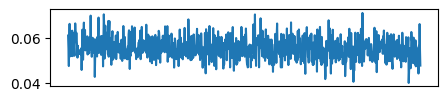

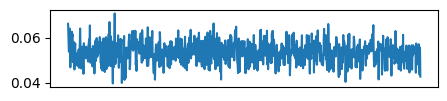

In [19]:
def train_epoch_cnn(cnn, loader, optimizer, epoch):
    cnn.train()
    losses = []
    for x, c in loader:
        x = x.cuda()
        c = c.cuda()
        eps = torch.randn_like(x)
        t = torch.rand(len(x), 1, 1, 1, device='cuda')
        z = x * (1 - t) + eps * t
        y_hat = cnn(z)
        loss = (F.one_hot(c, num_classes=10).float() - y_hat).pow(2).mean()
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        losses.append(loss.item())
    plt.figure(None, (5, 1))
    plt.xticks([])
    plt.plot(losses)
    plt.show()

for g in optim_cnn.param_groups:
    g['lr'] = 67e-4
for epoch in range(4):
    train_epoch_cnn(cnn, train_loader, optim_cnn, epoch)

In [ ]:
unet = UNET(16).cuda()
unet.compile()
optim = torch.optim.Adam(unet.parameters(), fused=True)

In [ ]:
def train_epoch(unet, loader, optimizer, epoch):
    unet.train()
    losses = []
    for x, _ in loader:
        x = x.cuda()

        eps = torch.randn_like(x)
        t = torch.rand(len(x), 1, 1, 1, device='cuda')
        z = x * (1 - t) + eps * t
        y = eps - x
        
        zt = torch.cat((z, t.repeat(1, 1, 28, 28)), dim=1)
        y_hat = unet(zt)
        loss = (y - y_hat).pow(2).mean()
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        losses.append(loss.item())
    plt.figure(None, (5, 1))
    plt.xticks([])
    plt.plot(losses)
    plt.show()

for g in optim.param_groups:
    g['lr'] = 67e-4 / 2
for epoch in range(670):
    train_epoch(unet, train_loader, optim, epoch)

In [ ]:
save_path = f"model.pth"
torch.save(unet.state_dict(), save_path)

print(f"Model successfully saved to {save_path}")


In [ ]:
m = []
for x, _ in train_loader:
    m.append(x)
m = torch.cat(m)
plt.imshow(m.mean(dim=0)[0])
print(sum(p.numel() for p in unet.parameters()))

In [ ]:
import torch
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import math

def generate_mnist_timelapse(unet, num_samples=16, steps=20, save_path=None):
    unet.eval()
    device = "cuda"

    x_t = torch.randn((num_samples, 1, 28, 28), device=device)

    c_labels = torch.randint(
        low=0,
        high=10,
        size=(num_samples,),
        device=device
    )


    ts = torch.linspace(1.0, 0.0, steps + 1, device=device)

    frames = []

    for t_from, t_to in zip(ts[:-1], ts[1:]):
        t = torch.full((num_samples, 1, 28, 28), t_from, device=device)

        zt = torch.cat((x_t, t), dim=1)
        with torch.no_grad():
            sigma = unet(zt)

        x_t.requires_grad = True
        nll = F.log_softmax(cnn(x_t), dim=1)[:, c_labels].sum()
        nll.backward()
        grad = x_t.grad
        x_t = x_t.detach()

        if t_from != 1:
            sigma = sigma + grad * t_from / (1 - t_from)
        
        x_0 = x_t - t_from * sigma
        x_0 = x_0.clamp(0, 1)
        sigma = (x_t - x_0) / t_from

        x_t = x_t + sigma * (t_to - t_from)

        frames.append(x_t.detach().cpu().clamp(0, 1))

    labels = c_labels.detach().cpu().tolist()

    nrow = int(math.sqrt(num_samples))
    ncol = math.ceil(num_samples / nrow)

    fig, axes = plt.subplots(nrow, ncol, figsize=(8, 8))
    axes = axes.flatten()

    image_plots = []

    for i in range(num_samples):
        img = axes[i].imshow(frames[0][i, 0], cmap="gray", animated=True)
        axes[i].set_title(f"prompt: {labels[i]:.1f}")
        axes[i].axis("off")
        image_plots.append(img)

    for i in range(num_samples, len(axes)):
        axes[i].axis("off")

    step_text = fig.suptitle("Step 1")

    def update(frame_idx):
        for i in range(num_samples):
            image_plots[i].set_array(frames[frame_idx][i, 0])

        step_text.set_text(f"Step {frame_idx + 1}/{len(frames)}")
        return image_plots + [step_text]

    ani = animation.FuncAnimation(
        fig,
        update,
        frames=len(frames),
        interval=300,
        blit=False
    )

    plt.tight_layout()

    if save_path is not None:
        ani.save(save_path, writer="pillow", fps=4)

    plt.show()

    return ani


ani = generate_mnist_timelapse(
    unet,
    num_samples=9,
    steps=30,
    save_path="mnist_timelapse.gif"
)

In [ ]:
from IPython.display import HTML

ani = generate_mnist_timelapse(unet, num_samples=16, steps=20)
HTML(ani.to_jshtml())